# Dimensionality Reduction Part 1: Feature Selection

## Decision Tree Example

In [141]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

X = np.array([[1.], [2.], [3.], [4.]])
y = np.array([0, 1, 0, 1])


tree = DecisionTreeClassifier(random_state=1)
tree.fit(X, y)
tree.score(X, y)

1.0

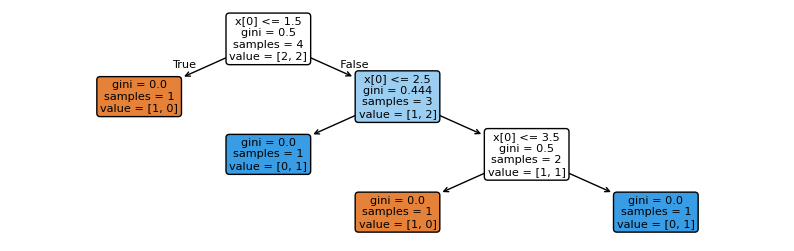

In [142]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(10, 3))

plot_tree(tree, 
          filled=True, 
          rounded=True) 

#plt.savefig('tree.pdf')
plt.show()

## Bernoulli variance

In [143]:
data_var = np.var(50*[0] + 50*[1]) # i.e., p = 0.5
data_var

np.float64(0.25)

In [144]:
0.5 * 0.5

0.25

## Scaling

In [145]:
np.random.seed(123)

data = np.random.random_sample(100)
np.var(data)

np.float64(0.06021177568505576)

In [146]:
np.var(data*10)

np.float64(6.021177568505576)

## VarianceThreshold

In [147]:
from sklearn.preprocessing import OneHotEncoder


X = [['blue'], ['green'], ['blue'], ['blue'], ['green'], ['red'], ['blue'], ['green']]
y = [0, 0, 1, 0, 0, 1, 0, 0]

enc = OneHotEncoder(drop='first')
enc.fit(X)
X_ohe = enc.transform(X)
X_ohe.toarray()

array([[0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.]])

In [148]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=(.8 * (1 - .8)))

sel.fit(X_ohe)
sel.transform(X_ohe).toarray()

array([[0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.]])

## Lasso Path

In [149]:
import pandas as pd
import numpy as np


df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                      'ml/machine-learning-databases/wine/wine.data',
                      header=None)

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)


df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

print('Class labels', np.unique(df_wine['Class label']))
df_wine.head()

Class labels [1 2 3]


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [150]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test =\
    train_test_split(X, y, 
                     test_size=0.3, 
                     random_state=0, 
                     stratify=y)

In [151]:
from sklearn.preprocessing import StandardScaler


sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [152]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='saga',
    max_iter=5000,
    random_state=0,
 )

lr.fit(X_train_std, y_train)
print('Training accuracy:', lr.score(X_train_std, y_train))
print('Test accuracy:', lr.score(X_test_std, y_test))

Training accuracy: 1.0
Test accuracy: 1.0


In [153]:
lr.intercept_

array([ 0.51986659,  0.62110517, -1.14097177])

In [154]:
np.set_printoptions(8)

In [155]:
lr.coef_[lr.coef_!=0].shape

(14,)

In [156]:
lr.coef_

array([[ 0.04673816,  0.        ,  0.        , -0.77728367,  0.        ,
         0.        ,  0.13436053,  0.        ,  0.        ,  0.        ,
         0.        ,  0.41260523,  0.87923468],
       [-1.47265008, -0.35464397, -0.92449336,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , -1.26172473,
         0.42465789,  0.        , -1.47799782],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -2.33409025,  0.        ,  0.        ,  0.        ,
        -0.79366558, -0.8458376 ,  0.        ]])

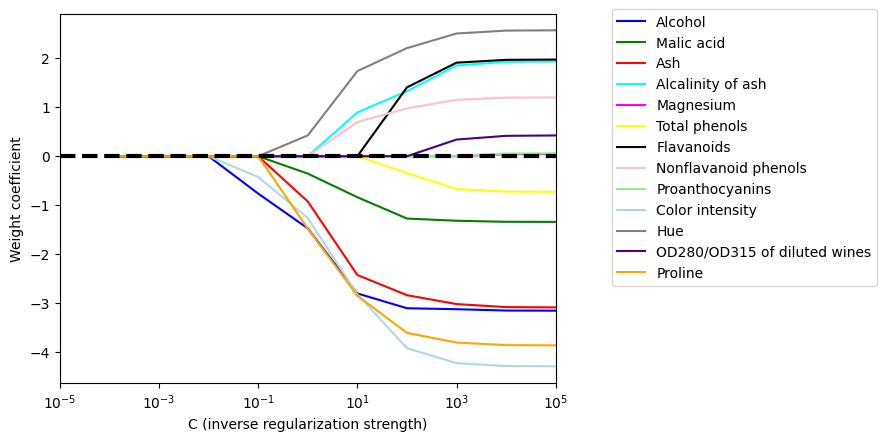

In [157]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.subplot(111)
    
colors = ['blue', 'green', 'red', 'cyan', 
          'magenta', 'yellow', 'black', 
          'pink', 'lightgreen', 'lightblue', 
          'gray', 'indigo', 'orange']

weights, params = [], []
for c in np.arange(-4., 6.):
    lr = LogisticRegression(
        penalty='l1',
        C=10.**c,
        solver='saga',
        max_iter=5000,
        random_state=0,
    )
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10**c)

weights = np.array(weights)

for column, color in zip(range(weights.shape[1]), colors):
    plt.plot(params, weights[:, column],
             label=df_wine.columns[column + 1],
             color=color)
plt.axhline(0, color='black', linestyle='--', linewidth=3)
plt.xlim([10**(-5), 10**5])
plt.ylabel('Weight coefficient')
plt.xlabel('C (inverse regularization strength)')
plt.xscale('log')
plt.legend(loc='upper left')
ax.legend(loc='upper center', 
          bbox_to_anchor=(1.38, 1.03),
          ncol=1, fancybox=True)
# plt.savefig('lasso-path.pdf', dpi=300, 
#             bbox_inches='tight', pad_inches=0.2)
plt.show()

## Random Forest

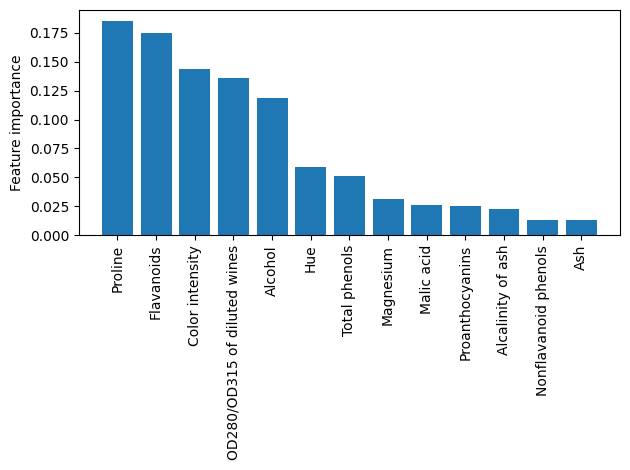

In [158]:
from sklearn.ensemble import RandomForestClassifier



forest = RandomForestClassifier(n_estimators=500,
                                random_state=1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

plt.ylabel('Feature importance')
plt.bar(range(X_train.shape[1]), 
        importances[indices],
        align='center')

feat_labels = df_wine.columns[1:]
plt.xticks(range(X_train.shape[1]), 
           feat_labels[indices], rotation=90)

plt.xlim([-1, X_train.shape[1]])

plt.tight_layout()
# plt.savefig('feature-importance.pdf', dpi=300)
plt.show()

In [159]:
# forest.estimators_

## Recursive Feature Elimination

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE



lr = LogisticRegression(solver='saga', max_iter=5000, random_state=123)

rfe = RFE(estimator=lr, n_features_to_select=5, step=1)
rfe.fit(X_train_std, y_train)

X_train_sub = rfe.transform(X_train_std)

### Which features are selected?

In [161]:
rfe.support_

array([ True, False, False, False, False, False,  True, False, False,
        True,  True, False,  True])

In [162]:
df_wine.columns[1:][rfe.support_]

Index(['Alcohol', 'Flavanoids', 'Color intensity', 'Hue', 'Proline'], dtype='object')

### RFE as Part of a Pipeline

In [163]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline


pipe = make_pipeline(RFE(estimator=lr, step=1),
                     KNeighborsClassifier())


parameters = {'rfe__n_features_to_select': range(1, 13), 
              'kneighborsclassifier__n_neighbors': range(1, 10) }

grid = GridSearchCV(pipe, param_grid=parameters, cv=10, n_jobs=-1)
grid.fit(X_train_std, y_train)

print('Best params:', grid.best_params_)
print('Best accuracy:', grid.best_score_)

Best params: {'kneighborsclassifier__n_neighbors': 9, 'rfe__n_features_to_select': 8}
Best accuracy: 0.9839743589743589


In [164]:
# Reduced feature set from grid search

grid.best_estimator_.score(X_test_std, y_test)

1.0

In [165]:
# Full feature set for reference

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_std, y_train)
knn.score(X_test_std, y_test)

0.9629629629629629

# Permutation Importance

## Permutation importance vs Random Forest impurity-based performance

In [166]:
from sklearn.ensemble import RandomForestClassifier


forest = RandomForestClassifier(n_estimators=100,
                                random_state=0)

forest.fit(X_train, y_train)

print('Training accuracy:', np.mean(forest.predict(X_train) == y_train)*100)
print('Test accuracy:', np.mean(forest.predict(X_test) == y_test)*100)

Training accuracy: 100.0
Test accuracy: 100.0


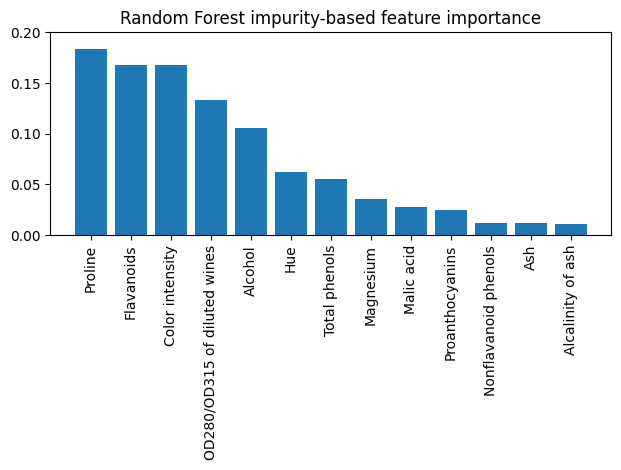

In [167]:
importance_vals = forest.feature_importances_
indices = np.argsort(importance_vals)[::-1]

# Plot the feature importances of the forest
plt.figure()
plt.title("Random Forest impurity-based feature importance")
plt.bar(range(X_train.shape[1]), importance_vals[indices])

plt.xticks(range(X_train.shape[1]), df_wine.columns[1:][indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylim([0, 0.2])

plt.tight_layout()
# plt.savefig('1.pdf')
plt.show()

In [168]:
from mlxtend.evaluate import feature_importance_permutation


imp_vals, imp_all = feature_importance_permutation(
    predict_method=forest.predict, 
    X=X_test,
    y=y_test,
    metric='accuracy',
    num_rounds=50,
    seed=0)

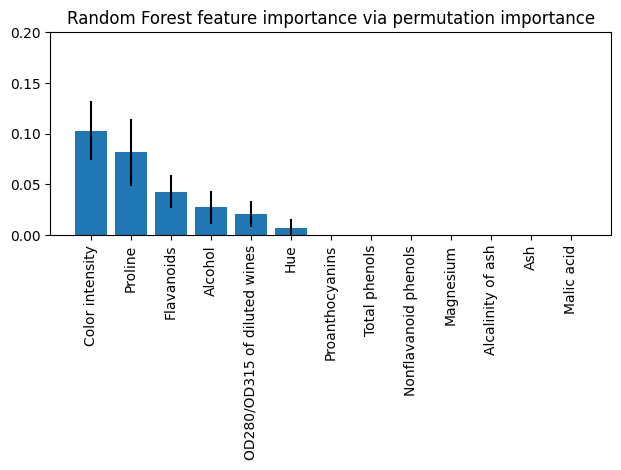

In [169]:
std = np.std(imp_all, axis=1)
indices = np.argsort(imp_vals)[::-1]

plt.figure()
plt.title("Random Forest feature importance via permutation importance")
plt.bar(range(X_train.shape[1]), imp_vals[indices], yerr=std[indices])

plt.xticks(range(X_train.shape[1]), df_wine.columns[1:][indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylim([0, 0.2])

plt.tight_layout()
# plt.savefig('2.pdf')
plt.show()

## Scikit-learn

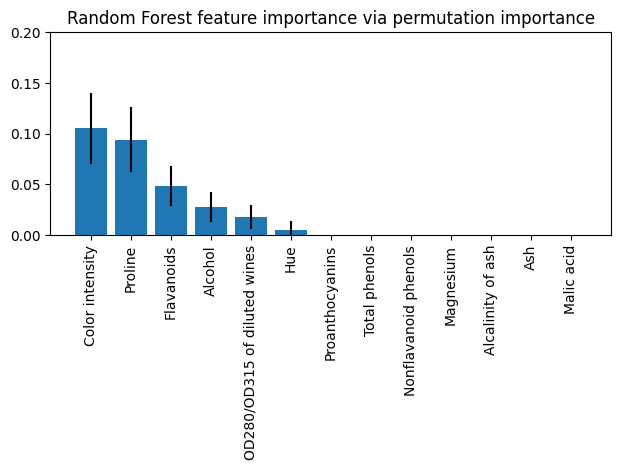

In [170]:
from sklearn.inspection import permutation_importance


forest = RandomForestClassifier(n_estimators=100,
                                random_state=0)

forest.fit(X_train, y_train)

result = permutation_importance(
    estimator=forest,
    X=X_test,
    y=y_test,
    scoring='accuracy',
    n_repeats=50,
    random_state=0
)


indices = np.argsort(result['importances_mean'])[::-1]

plt.figure()
plt.title("Random Forest feature importance via permutation importance")
plt.bar(
    range(X.shape[1]),
    result['importances_mean'][indices],
    yerr=result['importances_std'][indices]
)

plt.xticks(range(X.shape[1]), df_wine.columns[1:][indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.ylim([0, 0.2])

plt.tight_layout()
# plt.savefig('3.pdf')
plt.show()

## Permutation Importance and Using Random Features as a Control

## Add random column

In [171]:
import numpy as np


np.random.seed(123)
x1 = np.random.randn(X_train.shape[0]).reshape(-1, 1)
x2 = np.random.randn(X_test.shape[0]).reshape(-1, 1)

In [172]:
X_train_r = np.hstack((X_train, x1))
X_test_r = np.hstack((X_test, x2))
X_test_r.shape

(54, 14)

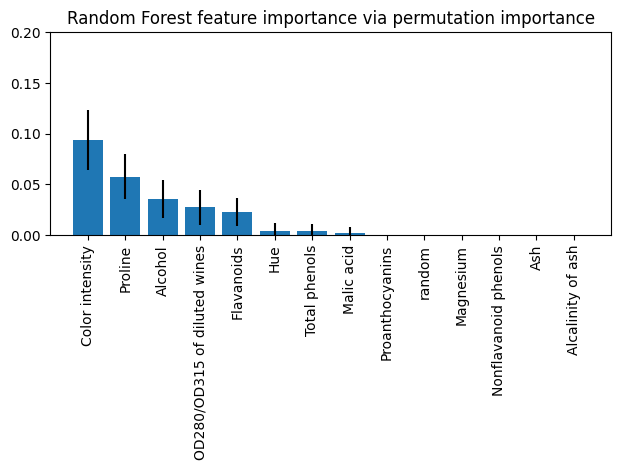

In [173]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier


forest = RandomForestClassifier(n_estimators=100,
                                random_state=0)

forest.fit(X_train_r, y_train)

result = permutation_importance(
    estimator=forest,
    X=X_test_r,
    y=y_test,
    scoring='accuracy',
    n_repeats=50,
    random_state=0
)


indices = np.argsort(result['importances_mean'])[::-1]

plt.figure()
plt.title("Random Forest feature importance via permutation importance")
plt.bar(
    range(X_train_r.shape[1]),
    result['importances_mean'][indices],
    yerr=result['importances_std'][indices]
)

feature_names = np.array(list(df_wine.columns[1:])+['random'])
plt.xticks(range(X_train_r.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X_train_r.shape[1]])
plt.ylim([0, 0.2])

plt.tight_layout()
# plt.savefig('4.pdf')
plt.show()

# Permutation Importance and Dealing with Correlated Features

In [174]:
import numpy as np


np.random.seed(123)

y = np.zeros(1000)
y[:500] = 1

x1 = np.random.randn(1000)

x2 = np.empty(1000)
x2[:500] = np.random.randn(500)
x2[500:] = np.random.randn(500)+4

x3 = x2 

X = np.vstack((x3, x2, x1)).swapaxes(1, 0)
X.shape

(1000, 3)

In [175]:
from sklearn.ensemble import RandomForestClassifier


forest = RandomForestClassifier(n_estimators=10,
                                random_state=123,
                                max_features=2)

forest.fit(X_train, y_train)

print('Training accuracy:', np.mean(forest.predict(X_train) == y_train)*100)
print('Test accuracy:', np.mean(forest.predict(X_test) == y_test)*100)

Training accuracy: 100.0
Test accuracy: 100.0


In [176]:
corr = np.corrcoef(X_train.T)
corr.shape

(13, 13)

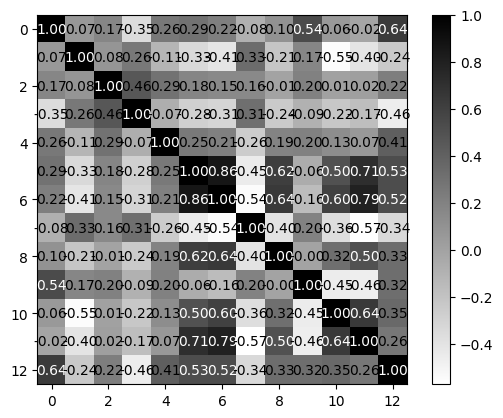

In [177]:
from mlxtend.plotting import heatmap


heatmap(corr, cmap='binary')
# plt.savefig('5.pdf')
plt.show()

In [178]:
from mlxtend.evaluate import feature_importance_permutation


imp_vals, imp_all = feature_importance_permutation(
    predict_method=forest.predict, 
    X=X_test,
    y=y_test,
    metric='accuracy',
    num_rounds=50,
    seed=123)

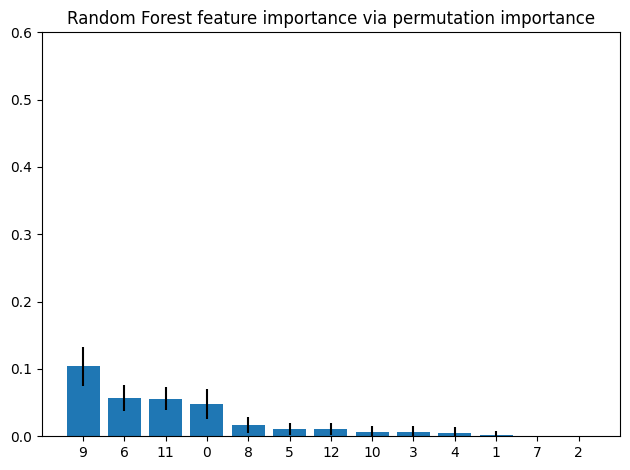

In [179]:
std = np.std(imp_all, axis=1)
indices = np.argsort(imp_vals)[::-1]

plt.figure()
plt.title("Random Forest feature importance via permutation importance")
plt.bar(range(X_train.shape[1]), imp_vals[indices], yerr=std[indices])

plt.xticks(range(X_train.shape[1]), indices)
plt.xlim([-1, X_train.shape[1]])
plt.ylim([0, 0.6])

plt.tight_layout()
# plt.savefig('6.pdf')
plt.show()

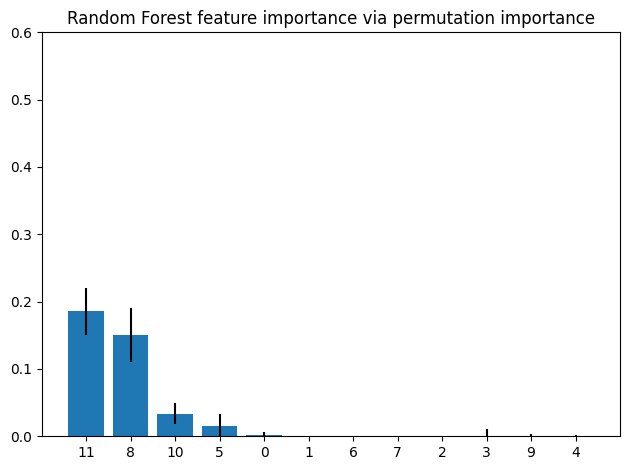

In [180]:
X_train = X_train[:, 1:]
X_test = X_test[:, 1:]

forest = RandomForestClassifier(n_estimators=10,
                                random_state=123,
                                max_features=2)

forest.fit(X_train, y_train)

imp_vals, imp_all = feature_importance_permutation(
    predict_method=forest.predict, 
    X=X_test,
    y=y_test,
    metric='accuracy',
    num_rounds=50,
    seed=123)

std = np.std(imp_all, axis=1)
indices = np.argsort(imp_vals)[::-1]

plt.figure()
plt.title("Random Forest feature importance via permutation importance")
plt.bar(range(X_train.shape[1]), imp_vals[indices], yerr=std[indices])

plt.xticks(range(X_train.shape[1]), indices)
plt.xlim([-1, X_train.shape[1]])
plt.ylim([0, 0.6])

plt.tight_layout()
# plt.savefig('7.pdf')
plt.show()

# Sequential Feature Selection

For more usage examples, also see http://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector

In [181]:
from sklearn.neighbors import KNeighborsClassifier


model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_std, y_train)

print('Training accuracy:', np.mean(model.predict(X_train_std) == y_train)*100)
print('Test accuracy:', np.mean(model.predict(X_test_std) == y_test)*100)

Training accuracy: 96.7741935483871
Test accuracy: 96.29629629629629


## Selecting the best 5 features

In [182]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


sfs1 = SFS(model, 
           k_features=5, 
           forward=True, 
           floating=False, 
           verbose=2,
           scoring='accuracy',
           n_jobs=-1,
           cv=5)


sfs1 = sfs1.fit(X_train_std, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  13 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  11 out of  13 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    0.0s finished

[2025-10-29 12:31:10] Features: 1/5 -- score: 0.7663333333333333[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  10 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.0s finished

[2025-10-29 12:31:10] Features: 2/5 -- score: 0.9436666666666665[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.0s finished

[2025-10-29 12:31:10

In [183]:
sfs1.k_feature_idx_

(0, 4, 6, 9, 12)

In [184]:
# you can also use sfs1.k_feature_names_ if you fit the model with a pandas DataFrame

df_wine.columns[1:][list(sfs1.k_feature_idx_)]

Index(['Alcohol', 'Magnesium', 'Flavanoids', 'Color intensity', 'Proline'], dtype='object')

In [185]:
X_train_sele = sfs1.transform(X_train_std)
X_test_sele = sfs1.transform(X_test_std)

model.fit(X_train_sele, y_train)
print('Training accuracy:', np.mean(model.predict(X_train_sele) == y_train)*100)
print('Test accuracy:', np.mean(model.predict(X_test_sele) == y_test)*100)

Training accuracy: 97.58064516129032
Test accuracy: 96.29629629629629


## Inspecting the results

In [186]:
sfs1.subsets_

{1: {'feature_idx': (6,),
  'cv_scores': array([0.8       , 0.64      , 0.8       , 0.8       , 0.79166667]),
  'avg_score': np.float64(0.7663333333333333),
  'feature_names': ('6',)},
 2: {'feature_idx': (6, 9),
  'cv_scores': array([1.        , 0.92      , 0.92      , 0.92      , 0.95833333]),
  'avg_score': np.float64(0.9436666666666665),
  'feature_names': ('6', '9')},
 3: {'feature_idx': (6, 9, 12),
  'cv_scores': array([1.        , 0.96      , 0.92      , 0.92      , 0.95833333]),
  'avg_score': np.float64(0.9516666666666665),
  'feature_names': ('6', '9', '12')},
 4: {'feature_idx': (0, 6, 9, 12),
  'cv_scores': array([1.  , 0.96, 0.92, 0.96, 1.  ]),
  'avg_score': np.float64(0.968),
  'feature_names': ('0', '6', '9', '12')},
 5: {'feature_idx': (0, 4, 6, 9, 12),
  'cv_scores': array([1.  , 1.  , 0.92, 0.96, 1.  ]),
  'avg_score': np.float64(0.976),
  'feature_names': ('0', '4', '6', '9', '12')}}

In [187]:
metric_dict = sfs1.get_metric_dict(confidence_interval=0.95)
metric_dict

{1: {'feature_idx': (6,),
  'cv_scores': array([0.8       , 0.64      , 0.8       , 0.8       , 0.79166667]),
  'avg_score': np.float64(0.7663333333333333),
  'feature_names': ('6',),
  'ci_bound': np.float64(0.08129345105118586),
  'std_dev': np.float64(0.06324906674761648),
  'std_err': np.float64(0.03162453337380824)},
 2: {'feature_idx': (6, 9),
  'cv_scores': array([1.        , 0.92      , 0.92      , 0.92      , 0.95833333]),
  'avg_score': np.float64(0.9436666666666665),
  'feature_names': ('6', '9'),
  'ci_bound': np.float64(0.0409235049425108),
  'std_dev': np.float64(0.031839877163358794),
  'std_err': np.float64(0.015919938581679394)},
 3: {'feature_idx': (6, 9, 12),
  'cv_scores': array([1.        , 0.96      , 0.92      , 0.92      , 0.95833333]),
  'avg_score': np.float64(0.9516666666666665),
  'feature_names': ('6', '9', '12'),
  'ci_bound': np.float64(0.03836784157233072),
  'std_dev': np.float64(0.029851484236317463),
  'std_err': np.float64(0.014925742118158732)},
 4:

In [188]:
df = pd.DataFrame.from_dict(metric_dict).T
df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(6,)","[0.8, 0.64, 0.8, 0.8, 0.7916666666666666]",0.766333,"(6,)",0.081293,0.063249,0.031625
2,"(6, 9)","[1.0, 0.92, 0.92, 0.92, 0.9583333333333334]",0.943667,"(6, 9)",0.040924,0.03184,0.01592
3,"(6, 9, 12)","[1.0, 0.96, 0.92, 0.92, 0.9583333333333334]",0.951667,"(6, 9, 12)",0.038368,0.029851,0.014926
4,"(0, 6, 9, 12)","[1.0, 0.96, 0.92, 0.96, 1.0]",0.968,"(0, 6, 9, 12)",0.038473,0.029933,0.014967
5,"(0, 4, 6, 9, 12)","[1.0, 1.0, 0.92, 0.96, 1.0]",0.976,"(0, 4, 6, 9, 12)",0.041129,0.032,0.016


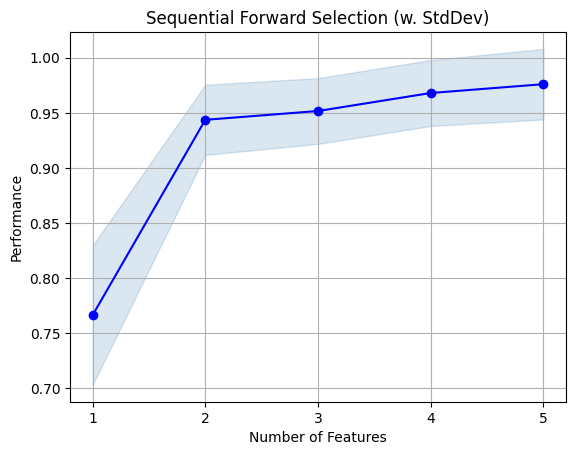

In [189]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


fig1 = plot_sfs(metric_dict, kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

## Select the best subset of any size

In [190]:
sfs1 = SFS(model, 
           k_features="best", # or (1, 13) and then select by hand 
           forward=True, 
           floating=False, 
           verbose=0,
           scoring='accuracy',
           cv=5)


sfs1 = sfs1.fit(X_train_std, y_train)

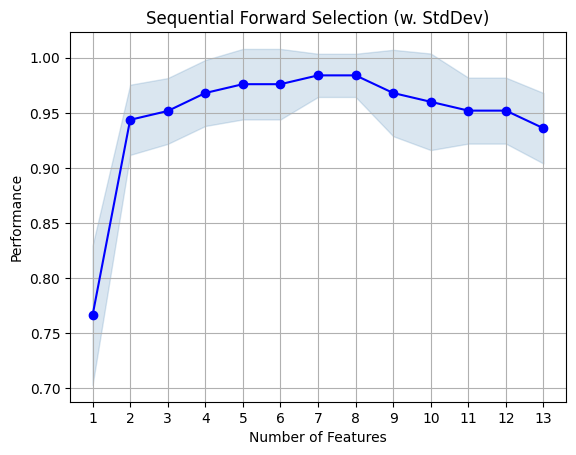

In [191]:
metric_dict = sfs1.get_metric_dict(confidence_interval=0.95)
fig1 = plot_sfs(metric_dict, kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

In [192]:
sfs1.k_feature_idx_

(0, 2, 4, 6, 9, 10, 12)

For more usage examples (including `GridSearchCV`, also see http://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector

## Exhaustive Search

Always a good idea to check the number of combinations to see if it is feasible:

$$\sum_{i=1}^{m} {m \choose i}$$

$${13 \choose 1} + {13 \choose 2} + \dots + {13  \choose 13} = 8191$$

In [193]:
from mlxtend.math import num_combinations



all_comb = np.sum([num_combinations(n=X.shape[1], k=i)
                   for i in range(1, X.shape[1]+1)])

all_comb

np.int64(7)

In [194]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS


efs1 = EFS(model, 
           min_features=1,
           max_features=X.shape[1],
           scoring='accuracy',
           print_progress=True,
           n_jobs=-1,
           cv=5)

efs1 = efs1.fit(X_train_std, y_train)

Features: 377/377

In [195]:
efs1.best_idx_

(0, 6, 12)

## Sequential Feature Selection in Scikit-learn

- Simpler interface without that many bells and whistles
- Use this if you are interested in a specific feature size and don't want to use floating variants

In [196]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS


sfs2 = SFS(model,
           n_features_to_select=5,
           direction='forward',
           scoring='accuracy',
           n_jobs=-1,
           cv=5)

sfs2 = sfs2.fit(X_train_std, y_train)

In [197]:
sfs2.get_support()
# np.arange(X.shape[1])[sfs2.support_]

array([ True, False, False, False,  True, False,  True, False, False,
        True, False, False,  True])

In [198]:
# Shape before applying feature selection
X_train_std.shape

(124, 13)

In [199]:
# Apply feature selection to keep the features selected by SFS
X_train_std_reduced = sfs2.transform(X_train_std)
X_train_std_reduced.shape

(124, 5)